Loading the data processed by hdWGCNA in R

In [1]:
import math
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [2]:
# Selecting the brain region
select_region = "Isocortex-1-IT-ET-Glut"

In [3]:
# Loading AnnData object
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / "AnnData/" / f"WMB-10Xv3-{select_region}-raw-wmeta.h5ad"
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 121827 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [4]:
# Count the number of cells in each class
class_counts = adata.obs["subclass"].value_counts()

# Identify classes with few cells
n_cells_threshold = 100

# Filter out the cells belonging to the identified classes
classes_to_remove = class_counts[class_counts < n_cells_threshold].index.tolist()
adata = adata[~adata.obs["subclass"].isin(classes_to_remove)].copy()

print(f"Classes with less than {n_cells_threshold} cells ({classes_to_remove}) have been removed.")
adata

Classes with less than 100 cells (['009 L2/3 IT PIR-ENTl Glut', '010 IT AON-TT-DP Glut', '008 L2/3 IT ENT Glut', '025 CA2-FC-IG Glut', '018 L2 IT PPP-APr Glut', '019 L2/3 IT PPP Glut', '016 CA1-ProS Glut', '017 CA3 Glut', '011 L2 IT ENT-po Glut', '014 LA-BLA-BMA-PA Glut', '024 L5 PPP Glut']) have been removed.


AnnData object with n_obs × n_vars = 121575 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [5]:
# Loading Module Eigengenes dataframe
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs")
modules_df = pd.read_csv(base_path / f"WMB-10Xv3-{select_region}-raw-mc-wgcna-modules.csv", index_col="Unnamed: 0")
modules_df.head()

,gene_name,module,color,kME_grey,kME_Glut-M1,kME_Glut-M2,kME_Glut-M3,kME_Glut-M4,kME_Glut-M5,kME_Glut-M6,kME_Glut-M7
ENSMUSG00000043659,ENSMUSG00000043659,grey,grey,-0.041859,0.025588,-0.041061,0.045359,0.147245,0.149132,-0.024783,-0.112368
ENSMUSG00000108532,ENSMUSG00000108532,Glut-M1,green,0.113287,0.406982,-0.137795,0.194830,-0.008591,0.047679,-0.136549,0.111784
ENSMUSG00000005716,ENSMUSG00000005716,Glut-M2,yellow,0.010592,-0.005589,0.187729,-0.070545,0.166084,0.012317,-0.017360,-0.081384
ENSMUSG00000053475,ENSMUSG00000053475,grey,grey,0.428535,-0.017418,-0.017903,0.066508,0.000075,-0.040867,-0.068429,0.102690
ENSMUSG00000053153,ENSMUSG00000053153,Glut-M3,blue,-0.012413,0.060220,-0.081600,0.234277,0.029518,0.041267,-0.050567,0.003529


In [6]:
modules_df = modules_df[modules_df["module"] != "grey"].copy()

In [8]:
# module_names = {
#     "Isocortex-M1": "Oligodendrocyte Myelination",
#     "Isocortex-M2": "Neuronal Projection",
#     "Isocortex-M3": "Immune Response",
#     "Isocortex-M4": "Vascular Morphogenesis",
#     "Isocortex-M5": "Developmental Signaling",
#     "Isocortex-M6": "Neural Development",
#     "Isocortex-M7": "Structural Morphogenesis",
#     "Isocortex-M8": "Extracellular Matrix",
#     "Isocortex-M9": "Axon Guidance",
# }

In [9]:
# # Rename the 'module' column in modules_df using module_names and save as a new dataframe
# modules_df_renamed = modules_df.copy()
# modules_df_renamed["module"] = modules_df_renamed["module"].map(module_names).fillna(modules_df_renamed["module"])
# modules_df_renamed.head()

## GO

In [7]:
from gprofiler import GProfiler

module_gene_dict = modules_df.groupby("module")["gene_name"].apply(list).to_dict()

gp = GProfiler(return_dataframe=True)
all_results = []

for module, genes in module_gene_dict.items():
    # gProfiler expects gene symbols or ENSEMBL IDs
    if len(genes) == 0:
        continue
    res = gp.profile(
        organism="mmusculus",
        query=genes,
        sources=['GO:BP'],
        user_threshold=0.05,
        significance_threshold_method='fdr'
    )
    if res.empty:
        continue
    res['module'] = module
    all_results.append(res)

results_df = pd.concat(all_results, ignore_index=True)

In [8]:
results_df.to_csv("outputs/glut_modules_go.csv")

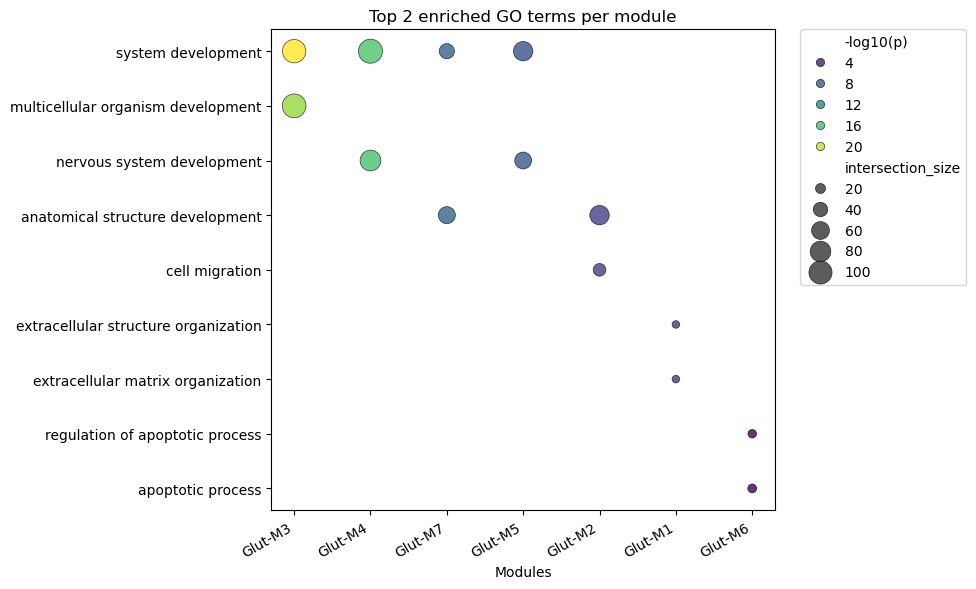

In [9]:
# ---------------------------------------------
# Parameters
# ---------------------------------------------
top_n = 2  # Top terms per cluster to include

# ---------------------------------------------
# Select top N enriched terms per cluster
# ---------------------------------------------
top_terms_df = (
    results_df
    .sort_values("p_value")
    .groupby("module")
    .head(top_n)
    .copy()
)

# Shorten term names for better plotting
top_terms_df["term_display"] = top_terms_df["name"].str.slice(0, 50)
top_terms_df["-log10(p)"] = -np.log10(top_terms_df["p_value"] + 1e-300)

# Optional: sort GO terms by frequency of appearance across clusters
term_order = (
    top_terms_df["term_display"]
    .value_counts()
    .index.tolist()
)

# ---------------------------------------------
# Create the Dot Plot
# ---------------------------------------------
plt.figure(figsize=(10, max(6, 0.4 * len(term_order))))
sns.scatterplot(
    data=top_terms_df,
    x="module",
    y="term_display",
    size="intersection_size",
    hue="-log10(p)",
    sizes=(30, 300),
    palette="viridis",
    edgecolor="black",
    alpha=0.8,
)

# Improve layout
plt.xticks(rotation=30, ha="right")
plt.ylabel("")
plt.xlabel("Modules")
plt.title(f"Top {top_n} enriched GO terms per module")

# Legends
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
# plt.savefig("figures/go_dotplot_Glut_CNA.svg")
plt.show()

## ME

In [7]:
from sklearn.decomposition import PCA

# Preprocess the data
sc.pp.normalize_total(adata, target_sum=1e4)  # Normalize counts per cell
sc.pp.log1p(adata)  # Log-transform the data
sc.pp.scale(adata)  # Scale the data

# Get unique modules and their gene lists
module_gene_dict = modules_df.groupby("module")["gene_name"].apply(list).to_dict()

# Store eigengenes in a DataFrame
eigengenes = pd.DataFrame(index=adata.obs_names)

for module, genes in module_gene_dict.items():
    # Filter genes present in adata
    genes_in_adata = [g for g in genes if g in adata.var_names]
    if len(genes_in_adata) < 2:
        continue  # Need at least 2 genes for PCA

    # Extract expression matrix for the module
    X = adata[:, genes_in_adata].X
    if not isinstance(X, np.ndarray):
        X = X.toarray()  # Convert sparse to dense if needed

    # Compute first principal component (eigengene)
    pca = PCA(n_components=1)
    eigengene = pca.fit_transform(X).flatten()
    eigengenes[module] = eigengene

eigengenes.head()

,Glut-M1,Glut-M2,Glut-M3,Glut-M4,Glut-M5,Glut-M6,Glut-M7
cell_label,,,,,,,
TGCAGATCATCAGTGT-416_A02,3.596392,1.098595,-3.086460,-1.868600,1.529370,2.087020,-4.514589
TGCATGAGTAGTCGGA-391_A03,0.748409,-2.967692,-0.565468,-2.192872,0.225951,0.318705,-3.481402
GTCCCATGTCTCGCGA-406_A01,0.107650,0.191274,-5.182115,-2.325131,1.685089,0.592957,-5.453021
TTTCACAGTCAGTTTG-416_A02,0.026584,4.231738,-3.966789,-0.419334,1.347894,4.311724,-0.768034
TGGATGTGTGGCACTC-416_A02,0.406358,0.733726,-3.589331,-4.012774,-1.574403,2.717662,-4.688951


In [ ]:
# custom_module_order = [
#  'Axon Guidance',
#  'Neuronal Projection',
#  'Developmental Signaling',
#  'Neural Development',
#  'Oligodendrocyte Myelination',
#  'Extracellular Matrix',
#  'Structural Morphogenesis',
#  'Vascular Morphogenesis',
#  'Immune Response'
#  ]

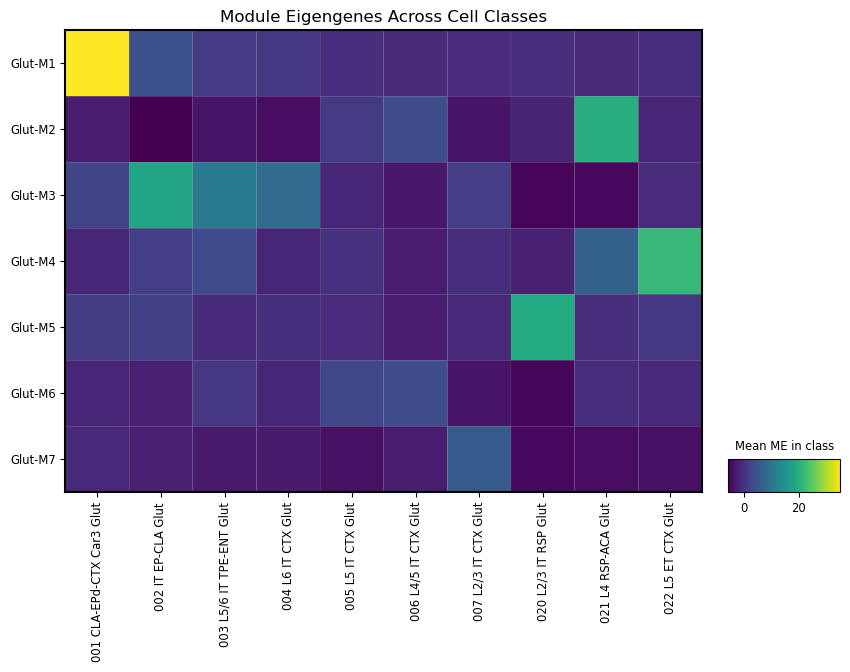

In [8]:
# Convert to AnnData (required for scanpy plotting)
adata_vis = sc.AnnData(eigengenes)
adata_vis.obs["subclass"] = adata.obs["subclass"]  # Add cell type labels

# Matrixplot
sc.pl.matrixplot(
    adata_vis,
    var_names=eigengenes.columns, # eigengenes.columns, custom_module_order
    groupby="subclass",
    swap_axes=True,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 6),  # Adjust size as needed
    title="Module Eigengenes Across Cell Classes",
    colorbar_title="Mean ME in class",
    cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    use_raw=False,
)

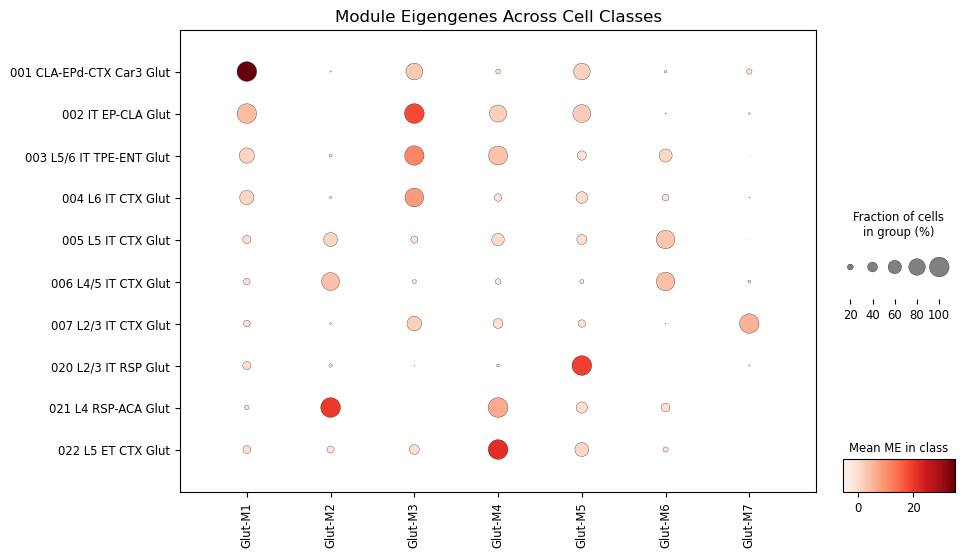

In [10]:
# Matrixplot
sc.pl.dotplot(
    adata_vis,
    var_names=eigengenes.columns,
    groupby="subclass",
    swap_axes=False,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 6),  # Adjust size as needed
    title="Module Eigengenes Across Cell Classes",
    colorbar_title="Mean ME in class",
    # cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    use_raw=False,
    save = "Glut_modules.svg"
)

In [13]:
# Adding MEs to AnnData object
merged_df = pd.merge(adata.obs, eigengenes, left_index=True, right_index=True)
merged_df.head()

,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,entity,brain_section_label,library_method,region_of_interest_acronym,donor_label,donor_genotype,...,cluster_color,region_of_interest_order,region_of_interest_color,Glut-M1,Glut-M2,Glut-M3,Glut-M4,Glut-M5,Glut-M6,Glut-M7
cell_label,,,,,,,,,,,,,,,,,,,,,
TGCAGATCATCAGTGT-416_A02,TGCAGATCATCAGTGT,416_A02,L8TX_201105_01_A01,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,ACA,Snap25-IRES2-Cre;Ai14-551639,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#246600,8,#00990A,3.596392,1.098595,-3.086460,-1.868600,1.529370,2.087020,-4.514589
TGCATGAGTAGTCGGA-391_A03,TGCATGAGTAGTCGGA,391_A03,L8TX_201015_01_C03,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,PL-ILA-ORB,Snap25-IRES2-Cre;Ai14-546759,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#246600,9,#8CCC00,0.748409,-2.967692,-0.565468,-2.192872,0.225951,0.318705,-3.481402
GTCCCATGTCTCGCGA-406_A01,GTCCCATGTCTCGCGA,406_A01,L8TX_201030_01_F11,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,ACA,Snap25-IRES2-Cre;Ai14-549927,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#246600,8,#00990A,0.107650,0.191274,-5.182115,-2.325131,1.685089,0.592957,-5.453021
TTTCACAGTCAGTTTG-416_A02,TTTCACAGTCAGTTTG,416_A02,L8TX_201105_01_A01,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,ACA,Snap25-IRES2-Cre;Ai14-551639,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#246600,8,#00990A,0.026584,4.231738,-3.966789,-0.419334,1.347894,4.311724,-0.768034
TGGATGTGTGGCACTC-416_A02,TGGATGTGTGGCACTC,416_A02,L8TX_201105_01_A01,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,ACA,Snap25-IRES2-Cre;Ai14-551639,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#246600,8,#00990A,0.406358,0.733726,-3.589331,-4.012774,-1.574403,2.717662,-4.688951


In [15]:
def plot_multiple_umaps(data, modules, x_col="x", y_col="y", fig_width=4, fig_height=4, cmap="viridis"):
    """
    Plots multiple UMAP visualizations for the specified modules.

    Parameters:
        data (pd.DataFrame): The dataframe containing UMAP coordinates and the module eigengenes.
        modules (list): List of module names to plot.
        x_col (str): Column name for the x-axis UMAP coordinate.
        y_col (str): Column name for the y-axis UMAP coordinate.
        fig_width (float): Width of each subplot.
        fig_height (float): Height of each subplot.
        cmap (str): Colormap for the scatter plots.

    Returns:
        None
    """
    n_cols = 4  # Number of columns for subplots
    n_rows = math.ceil(len(modules) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width * n_cols, fig_height * n_rows))
    axes = axes.flatten()

    for i, module in enumerate(modules):
        ax = axes[i]
        scatter = ax.scatter(
            data[x_col],
            data[y_col],
            s=0.5,
            c=data[module],
            cmap=cmap,
            marker='.',
            edgecolor='none'
        )

        ax.axis('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(module)

        fig.colorbar(scatter, ax=ax, orientation='vertical', label=module)

    # Turn off unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

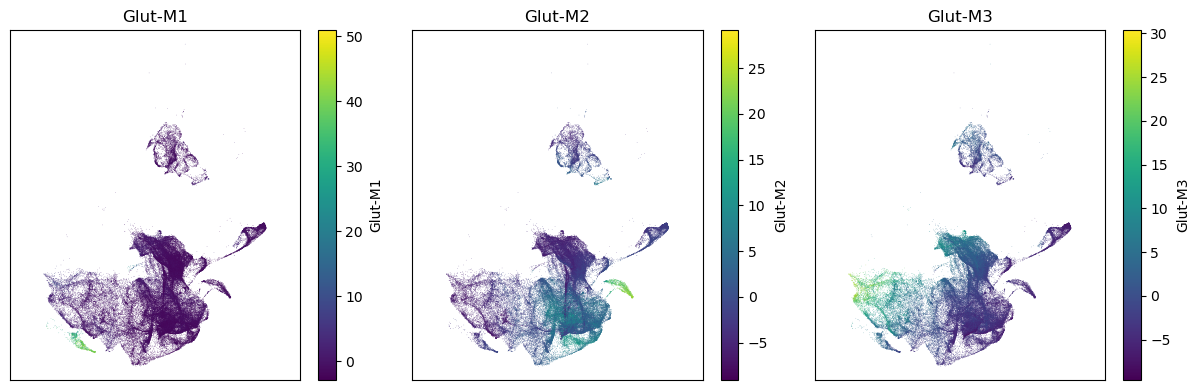

In [16]:
select_modules = ["Glut-M1", "Glut-M2", "Glut-M3"]
plot_multiple_umaps(merged_df, select_modules)

In [16]:
tau_scores = {}

for module in select_modules:
    tau_df = merged_df[["subclass", module]].copy()
    tau_df[module] = tau_df[module] - tau_df[module].min() + 1e-6  # Shift the eigengene values to ensure non-negativity

    # Compute average eigengene per cell class
    avg_expression = tau_df.groupby('subclass', observed=False)[module].mean()

    # Normalize by the maximum average expression
    max_expr = avg_expression.max()
    normalized_expr = avg_expression / max_expr

    # Compute tau score
    tau = np.sum(1 - normalized_expr) / (len(normalized_expr) - 1)
    tau_scores[module] = tau

# Print Tau scores for all modules
for module, score in tau_scores.items():
    print(f"Tau specificity score for {module} module: {score:.3f}")

Tau specificity score for Glut-M1 module: 0.913
Tau specificity score for Glut-M2 module: 0.753
Tau specificity score for Glut-M3 module: 0.618


In [18]:
adata_tracks.obs["subclass"].unique()

['005 L5 IT CTX Glut', '006 L4/5 IT CTX Glut', '004 L6 IT CTX Glut', '003 L5/6 IT TPE-ENT Glut', '002 IT EP-CLA Glut', '001 CLA-EPd-CTX Car3 Glut', '007 L2/3 IT CTX Glut', '022 L5 ET CTX Glut', '020 L2/3 IT RSP Glut', '021 L4 RSP-ACA Glut']
Categories (10, object): ['001 CLA-EPd-CTX Car3 Glut', '002 IT EP-CLA Glut', '003 L5/6 IT TPE-ENT Glut', '004 L6 IT CTX Glut', ..., '007 L2/3 IT CTX Glut', '020 L2/3 IT RSP Glut', '021 L4 RSP-ACA Glut', '022 L5 ET CTX Glut']

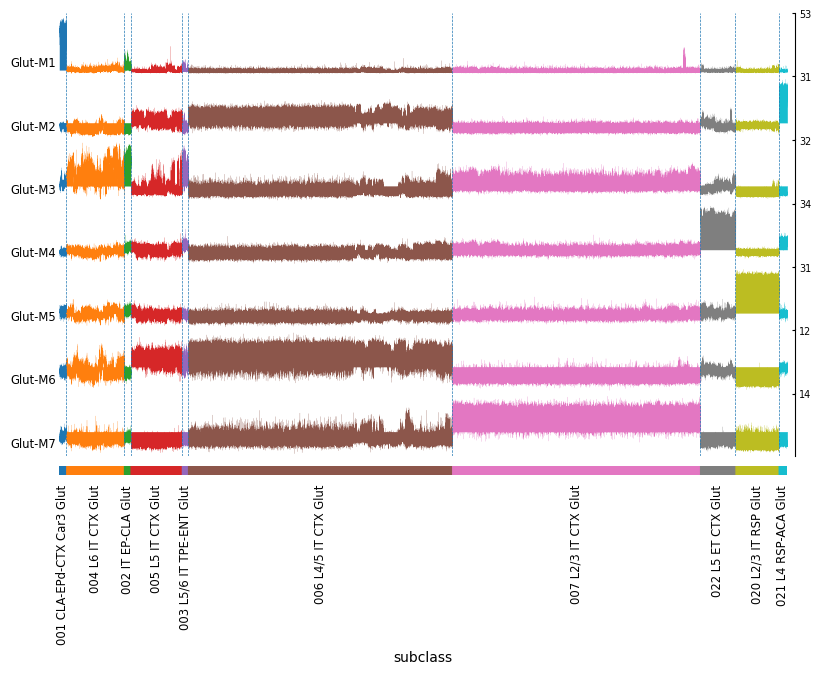

In [21]:
# Add all module eigengenes to AnnData and class labels
all_modules = [col for col in merged_df.columns if col in module_gene_dict.keys()]
adata_tracks = sc.AnnData(merged_df[all_modules])
adata_tracks.obs["subclass"] = merged_df["subclass"].astype("category")  # Ensure categorical dtype

# Setting the r-order of subclasses for plotting
desired_order = ['001 CLA-EPd-CTX Car3 Glut', '004 L6 IT CTX Glut', '002 IT EP-CLA Glut',
'005 L5 IT CTX Glut', '003 L5/6 IT TPE-ENT Glut', '006 L4/5 IT CTX Glut',
'007 L2/3 IT CTX Glut', '022 L5 ET CTX Glut', '020 L2/3 IT RSP Glut', '021 L4 RSP-ACA Glut']
adata_tracks.obs["subclass"] = adata_tracks.obs["subclass"].cat.reorder_categories(desired_order, ordered=True)

# Plot tracksplot of module eigengenes across cell classes
sc.pl.tracksplot(
    adata_tracks,
    var_names=all_modules,
    groupby="subclass",
    figsize=(10, 6),
    dendrogram=False,
    title="Tracksplot of Module Eigengenes Across Cell Classes",
    # cmap="viridis"
    save = "_glut_module_eigengenes.png"
)

In [21]:
n_top_genes_per_module = 2  # Set the number of top genes to select per module

# Create an empty list to store dataframes for each module
top_genes_by_module = []

# Iterate through each unique module in the "module" column
for module_name in modules_df["module"].unique():
    # Filter the dataframe for the current module
    module_genes = modules_df[modules_df["module"] == module_name]
    
    # Sort the genes by the corresponding kME column in descending order
    sorted_genes = module_genes.sort_values(by=f"kME_{module_name}", ascending=False)
    
    # Select the top genes (you can adjust the number of top genes as needed)
    top_genes = sorted_genes.head(n_top_genes_per_module)
    
    # Append the top genes dataframe to the list
    top_genes_by_module.append(top_genes)

# Combine all the top genes dataframes into a single dataframe
top_genes_df = pd.concat(top_genes_by_module, ignore_index=True)

# Display the resulting dataframe
top_genes_df.head()

,gene_name,module,color,kME_grey,kME_Glut-M1,kME_Glut-M2,kME_Glut-M3,kME_Glut-M4,kME_Glut-M5,kME_Glut-M6,kME_Glut-M7
0,ENSMUSG00000029101,Glut-M1,green,0.017186,0.782246,-0.189586,0.305623,-0.027476,0.022457,-0.112543,0.001754
1,ENSMUSG00000026156,Glut-M1,green,0.015430,0.749794,-0.075967,0.109233,-0.015065,0.089474,-0.069743,-0.022126
2,ENSMUSG00000087141,Glut-M2,yellow,-0.281473,-0.107490,0.769603,-0.499827,-0.060892,-0.161784,0.672696,-0.484246
3,ENSMUSG00000096914,Glut-M2,yellow,-0.466192,-0.145211,0.769541,-0.428206,0.073751,-0.295373,0.824013,-0.458252
4,ENSMUSG00000020524,Glut-M3,blue,-0.004929,0.099940,-0.495552,0.696169,0.264481,-0.157296,-0.199720,0.311549


In [22]:
gene_names_df = adata.var.copy()

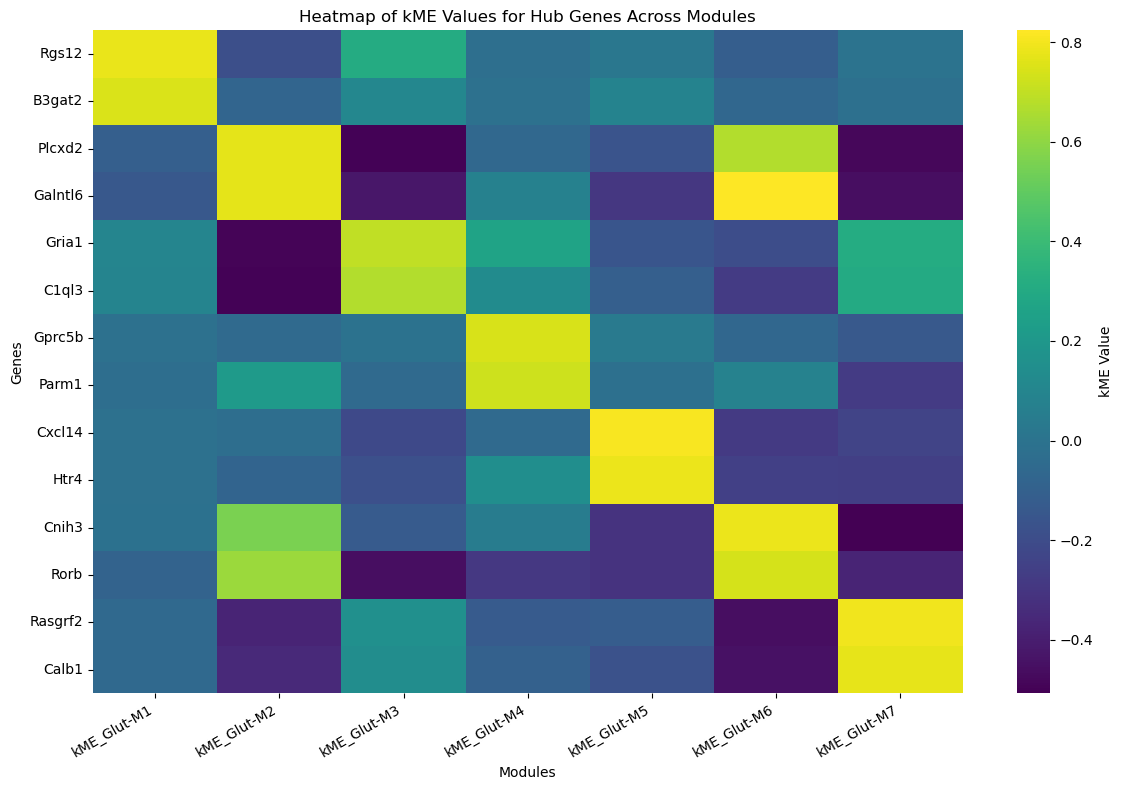

In [26]:
# Map gene IDs to gene symbols
gene_symbol_mapping = gene_names_df["gene_symbol"].to_dict()
top_genes_df["gene_symbol"] = top_genes_df["gene_name"].map(gene_symbol_mapping)

# Prepare the data for the heatmap
heatmap_data = top_genes_df.set_index("gene_symbol")[[f"kME_{module}" for module in top_genes_df["module"].unique()]]
# heatmap_data.columns = [
#     module_names.get(col.replace("kME_", ""), col.replace("kME_", ""))
#     for col in heatmap_data.columns
# ]

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap="viridis",
    annot=False,
    cbar_kws={"label": "kME Value"}
)

# Set axis labels and title
plt.xticks(rotation=30, ha="right")
plt.xlabel("Modules")
plt.ylabel("Genes")
plt.title("Heatmap of kME Values for Hub Genes Across Modules")
plt.savefig("figures/heatmap_kME_Glut.svg")
plt.tight_layout()
plt.show()

### Overlap with DEGs

In [27]:
# Loading the DEG dataframe
group_by = "subclass"
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
deg_path = base_path / "outputs/DEG/" / f"WMB-10Xv3-{select_region}-DEG-{group_by}.csv"
deg_results = pd.read_csv(deg_path)
deg_results.head(3)

,001 CLA-EPd-CTX Car3 Glut,002 IT EP-CLA Glut,003 L5/6 IT TPE-ENT Glut,004 L6 IT CTX Glut,005 L5 IT CTX Glut,006 L4/5 IT CTX Glut,007 L2/3 IT CTX Glut,020 L2/3 IT RSP Glut,021 L4 RSP-ACA Glut,022 L5 ET CTX Glut
0,Synpr,Sulf1,Fxyd6,Cdh9,Il1rapl2,Rorb,Rasgrf2,Tshz2,Cbln1,Bcl11b
1,Nr4a2,Nnat,Cnr1,Sema3e,Sulf2,Kcnk2,Rgs6,Slc17a6,Parm1,Fezf2
2,Rgs12,Chst11,Timp2,Bmp3,Tmsb10,Nrsn1,Calb1,Zfpm2,Ccdc136,Parm1


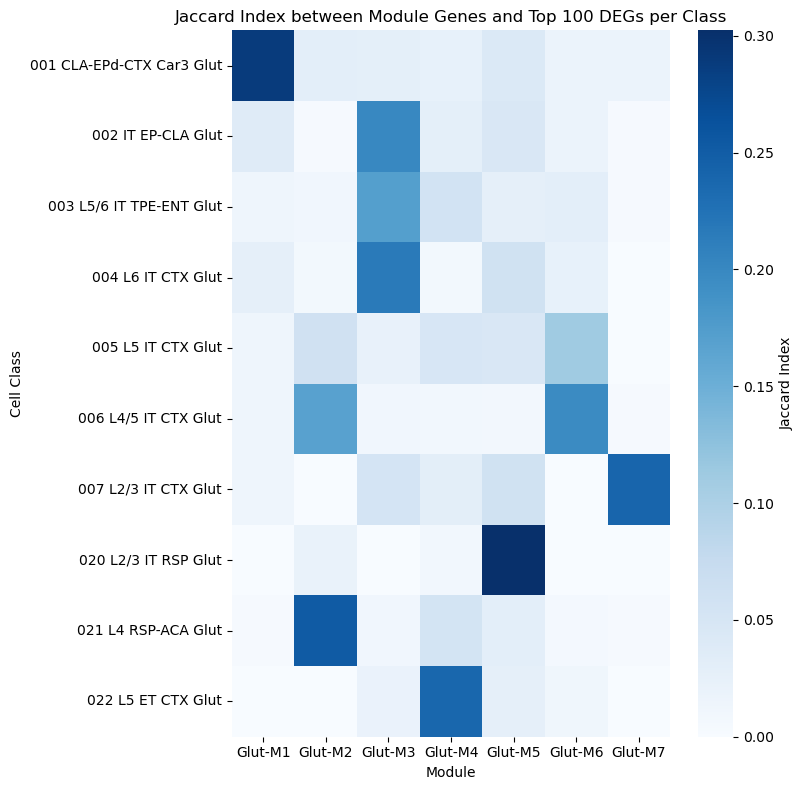

In [31]:
# 1. Get top 100 DEGs per class from deg_results (each column is a class, values are gene names)
top_n_deg = 100
deg_sets = {
    cls: set(deg_results[cls].dropna().head(top_n_deg))
    for cls in deg_results.columns
}

# 2. Build module gene sets (using gene symbols)
gene_symbol_map = adata.var["gene_symbol"].to_dict()
module_gene_sets = {
    mod: set([gene_symbol_map.get(g, g) for g in genes if gene_symbol_map.get(g, g) is not None])
    for mod, genes in module_gene_dict.items()
}

# 3. Compute Jaccard index matrix
import pandas as pd
jaccard_matrix = pd.DataFrame(
    index=module_gene_sets.keys(),
    columns=deg_sets.keys(),
    dtype=float
)

for mod, mod_genes in module_gene_sets.items():
    for cls, deg_genes in deg_sets.items():
        intersection = len(mod_genes & deg_genes)
        union = len(mod_genes | deg_genes)
        jaccard = intersection / union if union > 0 else 0.0
        jaccard_matrix.loc[mod, cls] = jaccard

# 4. Plot heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(
    jaccard_matrix.astype(float).T,
    annot=False,
    fmt=".2f",
    cmap="Blues",
    cbar_kws={"label": "Jaccard Index"}
)
plt.title("Jaccard Index between Module Genes and Top 100 DEGs per Class")
plt.xlabel("Module")
plt.ylabel("Cell Class")
plt.tight_layout()
plt.savefig("figures/heatmap_jaccard_index_Glut_CNA.svg")
plt.show()